In [33]:
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [34]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

<Figure size 640x480 with 0 Axes>

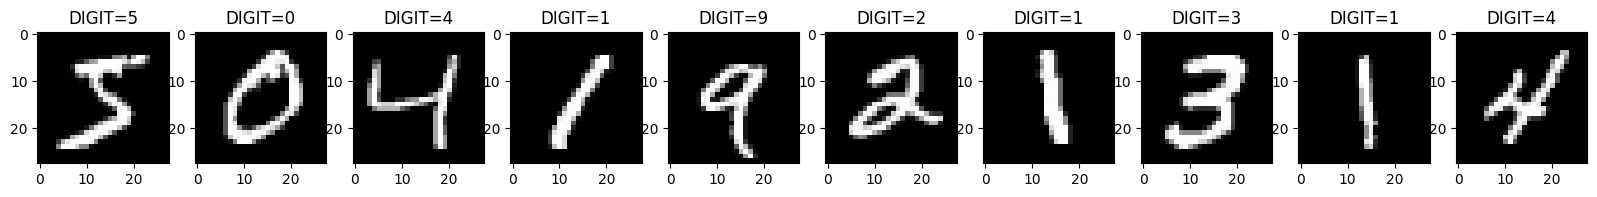

In [35]:
import matplotlib.pyplot as plt
plt.gray()
figure, axis = plt.subplots(ncols=10, figsize=(20,20))
for index in range(10):
   axis[index].imshow(X_train[index])
   axis[index].set_title(f"DIGIT={y_train[index]}")
plt.show()  

In [37]:
X_train.shape

(60000, 28, 28)

In [38]:
X_train = X_train.reshape(60000,28,28,1)

In [39]:
X_test.shape

(10000, 28, 28)

In [40]:
X_test = X_test.reshape(10000,28,28,1)

In [41]:
single_image = X_train[0]

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Input

![CNN](cnn.png)

In [43]:
model = Sequential()
model.add(Input((28,28,1)))
model.add(Conv2D(filters=32,kernel_size=(4,4),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(100,activation='relu'))
model.add(Dense(units = 10,activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 25, 25, 32)          │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │         460,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 462,454 (1.76 MB)

 Trainable params: 462,454 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
X_train_scaled = X_train/255.0
X_test_scaled = X_test/255.0
X_train_scaled.shape

(60000, 28, 28, 1)

In [46]:

history3 = model.fit(X_train_scaled, y_train, epochs=10, validation_split=0.3)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9485 - loss: 0.1710 - val_accuracy: 0.9763 - val_loss: 0.0770
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9831 - loss: 0.0556 - val_accuracy: 0.9746 - val_loss: 0.0824
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9886 - loss: 0.0360 - val_accuracy: 0.9798 - val_loss: 0.0660
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9920 - loss: 0.0256 - val_accuracy: 0.9825 - val_loss: 0.0626
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9940 - loss: 0.0182 - val_accuracy: 0.9834 - val_loss: 0.0596
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9960 - loss: 0.0129 - val_accuracy: 0.9826 - val_loss: 0.0699
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9969 - loss: 0.0096 - val_accuracy: 0.9837 - val_loss: 0.0642
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9973 -

### **Prediction**

In [2]:
!pip install opencv-python

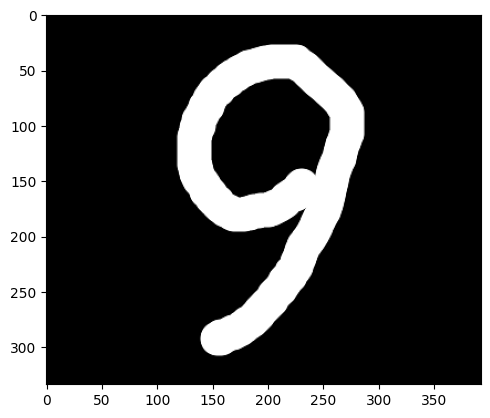

In [56]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('9.png')
plt.imshow(img)
plt.show()

In [57]:
img.shape

(334, 393, 3)

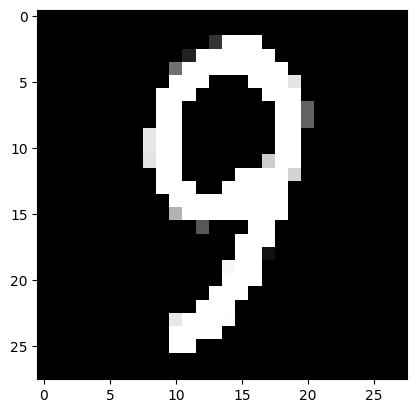

In [58]:
img_resized = tf.image.resize(img,size=(28,28))
gray_image = tf.image.rgb_to_grayscale(img_resized)
plt.imshow(gray_image)

In [59]:
predicted = model.predict(np.expand_dims(gray_image/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [60]:
print(np.argmax(predicted))

9


### **Saving the trained model**

In [ ]:
import os
model.save(os.path.join('models','cnn_image_classifier_V1.h5'))

In [ ]:
from tensorflow.keras.models import load_model
new_model = load_model('models/cnn_image_classifier_V1.h5')

In [ ]:
new_predicted_value = np.argmax(new_model.predict(X_train_scaled[0:1]))
print(new_predicted_value)